In [1]:
# import libraries is requires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('HR_comma_sep.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [4]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
data['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [6]:
data['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [7]:
data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
data['average_montly_hours'].value_counts()

average_montly_hours
135    153
156    153
149    148
151    147
160    136
      ... 
297      7
288      6
299      6
303      6
96       6
Name: count, Length: 215, dtype: int64

In [9]:
data['average_montly_hours'].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Name: average_montly_hours, Length: 14999, dtype: bool

In [10]:
# Perform data quality checks by checking for missing values, if any.
data.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

### Data types present

The dataset (`HR_comma_sep.csv`) has 14,999 rows × 10 columns, with no missing values.

**Numeric (continuous) — `float64`**
| Column | Description |
|---|---|
| `satisfaction_level` | Employee satisfaction score (0–1) |
| `last_evaluation` | Last performance evaluation score (0–1) |

**Numeric (discrete / count or binary) — `int64`**
| Column | Description |
|---|---|
| `number_project` | Number of projects assigned |
| `average_montly_hours` | Average monthly working hours |
| `time_spend_company` | Years spent at the company |
| `Work_accident` | Binary (0/1) — had a workplace accident |
| `left` | Binary (0/1) — target variable, whether employee left |
| `promotion_last_5years` | Binary (0/1) — promoted in last 5 years |

**Categorical — `object`/`str`**
| Column | Description |
|---|---|
| `sales` | Department (10 categories: sales, accounting, hr, technical, support, management, IT, product_mng, marketing, RandD) |
| `salary` | Salary level (3 categories: low, medium, high — ordinal) |

**Summary:** 8 numeric columns (2 continuous + 6 discrete, 3 of which are binary flags) and 2 categori

In [11]:
# Understand what factors contributed most to employee turnover at EDA.
numeric_features = data.select_dtypes(include=[np.number]).columns
numeric_features


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years'],
      dtype='str')

In [12]:
str_features = data.select_dtypes(include=['object','str']).columns
str_features

Index(['sales', 'salary'], dtype='str')

                       satisfaction_level  last_evaluation  number_project  \
satisfaction_level               1.000000         0.105021       -0.142970   
last_evaluation                  0.105021         1.000000        0.349333   
number_project                  -0.142970         0.349333        1.000000   
average_montly_hours            -0.020048         0.339742        0.417211   
time_spend_company              -0.100866         0.131591        0.196786   
Work_accident                    0.058697        -0.007104       -0.004741   
left                            -0.388375         0.006567        0.023787   
promotion_last_5years            0.025605        -0.008684       -0.006064   

                       average_montly_hours  time_spend_company  \
satisfaction_level                -0.020048           -0.100866   
last_evaluation                    0.339742            0.131591   
number_project                     0.417211            0.196786   
average_montly_hours         

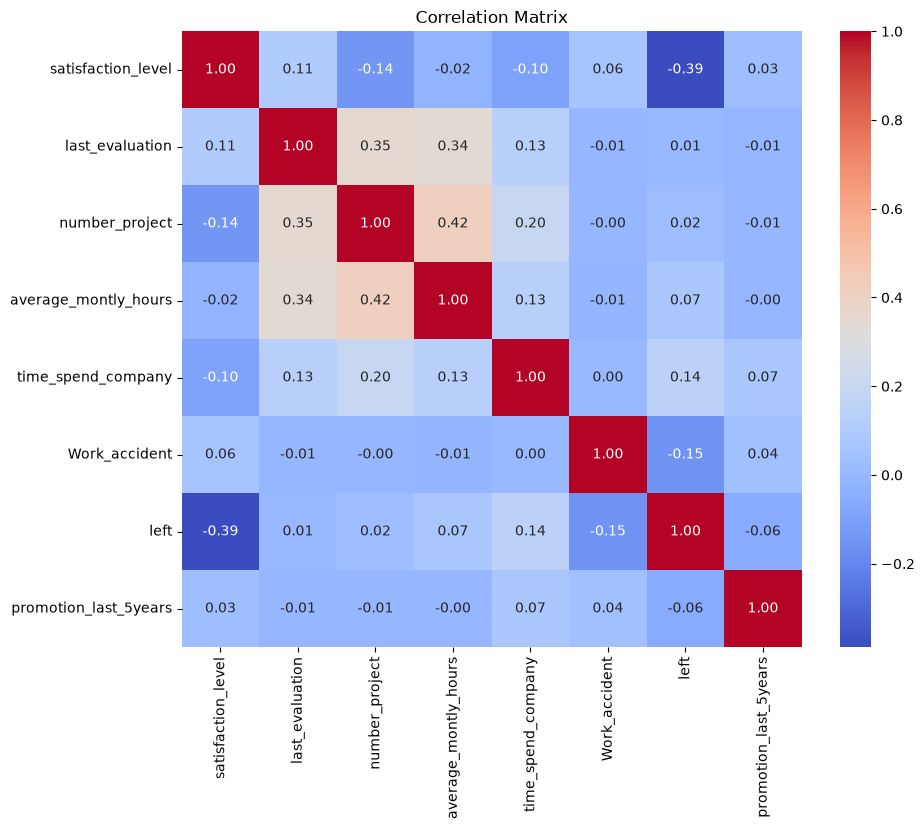

In [13]:
# Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
print(data[numeric_features].corr())
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Interpreting the correlation matrix

`data[numeric_features].corr()` computes the pairwise **Pearson correlation coefficient** (range -1 to +1) between every numeric column. A value near **+1** means the two variables move together, near **-1** means they move oppositely, and near **0** means little to no linear relationship.

**Correlation with the target (`left`), strongest first:**
| Feature | Correlation with `left` | Interpretation |
|---|---|---|
| `satisfaction_level` | **-0.39** | Strongest driver — lower satisfaction is strongly associated with employees leaving |
| `Work_accident` | -0.15 | Employees who had a workplace accident are (slightly) less likely to leave |
| `time_spend_company` | +0.14 | Employees who have stayed longer are somewhat more likely to leave |
| `average_montly_hours` | +0.07 | Weak positive relationship — more hours, slightly more likely to leave |
| `promotion_last_5years` | -0.06 | Weak — recently promoted employees are slightly less likely to leave |
| `number_project` | +0.02 | Negligible |
| `last_evaluation` | +0.01 | Negligible |

**Other notable relationships between features (not the target):**
- `number_project` & `average_montly_hours` (**+0.42**) — employees on more projects tend to work more hours.
- `last_evaluation` & `number_project` (**+0.35**) and `last_evaluation` & `average_montly_hours` (**+0.34**) — better-evaluated employees tend to handle more projects and work longer hours.

**Takeaway:** `satisfaction_level` is by far the most important numeric predictor of turnover i

In [14]:
# satisfaction_level ,last_evaluation, average_montly_hours
# Most common values, Outliers,Skewness, Normal distribution, Multiple groups of employees

data[['satisfaction_level','last_evaluation','average_montly_hours']].describe()

,satisfaction_level,last_evaluation,average_montly_hours
count,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,201.050337
std,0.248631,0.171169,49.943099
min,0.090000,0.360000,96.000000
25%,0.440000,0.560000,156.000000
50%,0.640000,0.720000,200.000000
75%,0.820000,0.870000,245.000000
max,1.000000,1.000000,310.000000


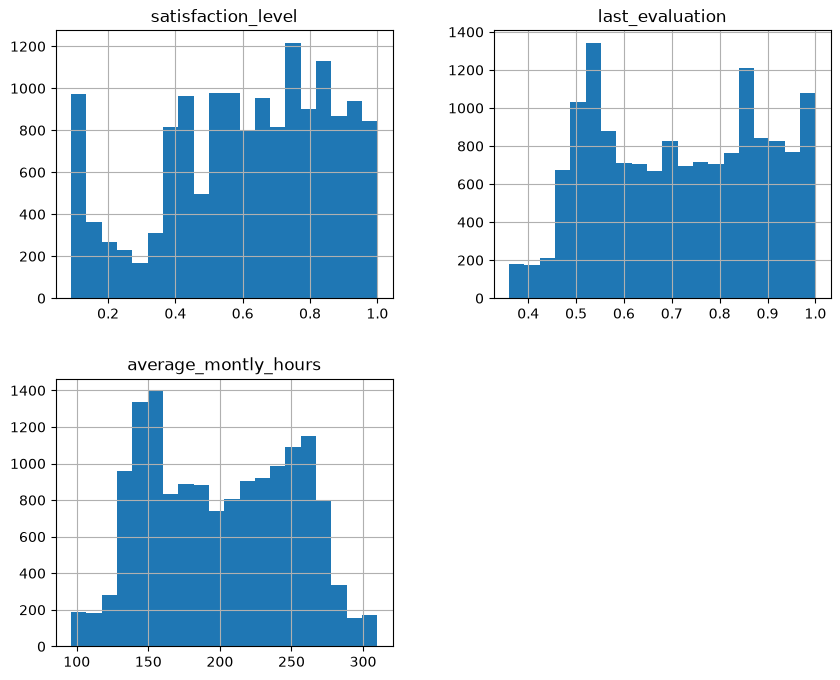

In [15]:
# Histogram, KDE plot, Distribution, Mean, Median, Skewness, Outliers

data[['satisfaction_level','last_evaluation','average_montly_hours']].hist(bins=20, figsize=(10, 8))
plt.show()

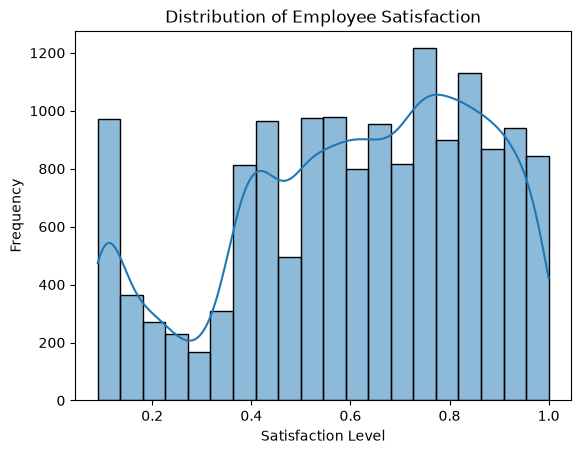

In [16]:
# Draw the distribution plot
# Employee Satisfaction (use column satisfaction_level)
sns.histplot(data['satisfaction_level'], kde=True, bins=20)
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Satisfaction')
plt.show()

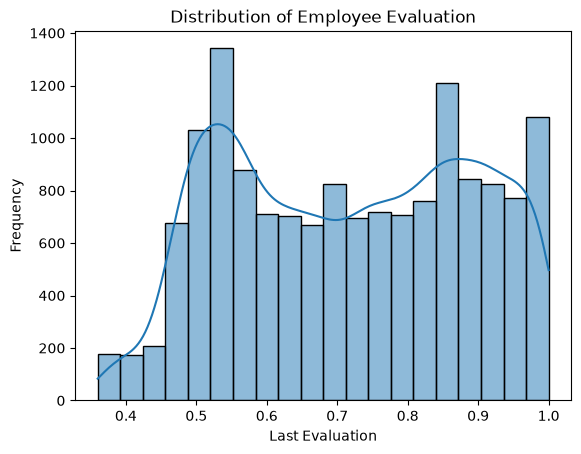

In [17]:
# Employee Evaluation (use column last_evaluation)
sns.histplot(data['last_evaluation'], kde=True, bins=20)
plt.xlabel('Last Evaluation')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Evaluation')
plt.show()

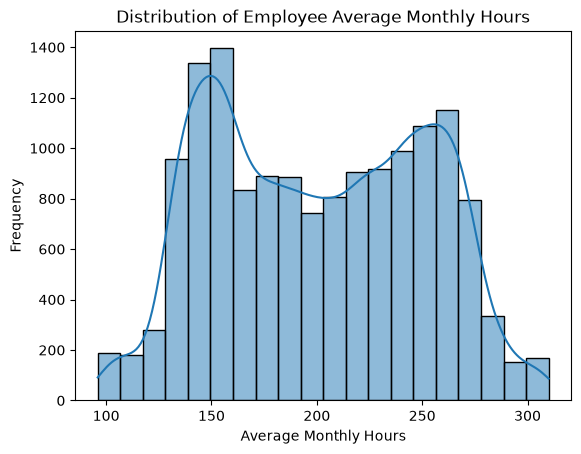

In [18]:
# Employee Average Monthly Hours (use column average_montly_hours)
sns.histplot(data['average_montly_hours'], kde=True, bins=20)
plt.xlabel('Average Monthly Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Average Monthly Hours')
plt.show()

### Distribution analysis — `satisfaction_level`, `last_evaluation`, `average_montly_hours`

| Feature | Skewness | Mean vs Median | Shape / Outliers |
|---|---|---|---|
| `satisfaction_level` | -0.48 (mildly left-skewed) | 0.61 vs 0.64 | **Multi-modal** — clear clusters near ~0.1 (very dissatisfied), ~0.4, and ~0.7–1.0 (highly satisfied), with a dip around 0.2–0.3. Not a single "normal" shape — this signals multiple distinct employee segments rather than outliers. |
| `last_evaluation` | -0.03 (~symmetric) | 0.72 vs 0.72 | Roughly **bimodal**, humps around 0.55 and 0.85–1.0. Range 0.36–1.0, no extreme outliers. |
| `average_montly_hours` | 0.05 (~symmetric) | 201 vs 200 | Roughly **bimodal**, humps around 150–160 hrs (underworked) and 250–260 hrs (overworked). Range 96–310, no extreme outliers. |

**Inference:** none of the three features follows a simple unimodal/normal distribution — each shows two or three sub-groups of employees (e.g., low vs. high satisfaction, under- vs. over-worked). This hints that employee behavior/turnover is driven by distinct segments rather than a single continuous trend, which the project-count analysis below confirms.

number_project
4    4365
3    4055
5    2761
2    2388
6    1174
7     256
Name: count, dtype: int64


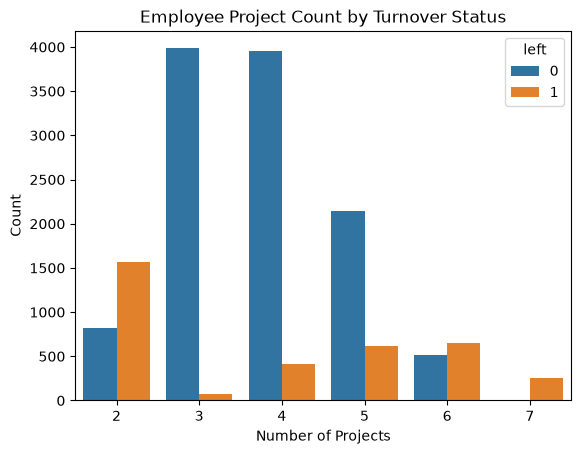

In [19]:
# Draw the bar plot of the employee project count of both employees who left and stayed in the organization
# (use column number_project and hue column left), and give your inferences from the plot.
print(data['number_project'].value_counts())
sns.countplot(data=data, x='number_project', hue='left')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.title('Employee Project Count by Turnover Status')
plt.show()

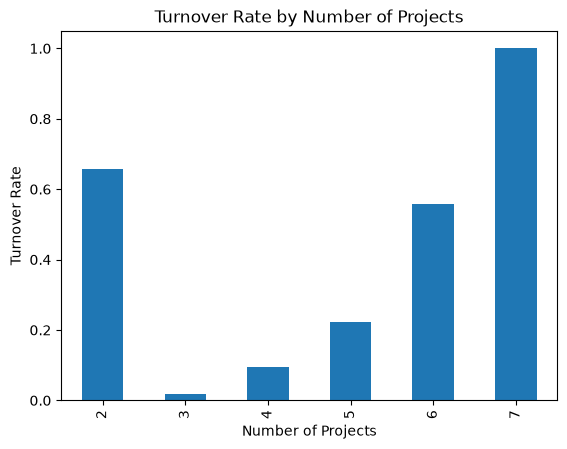

In [20]:
# Do employees with many projects leave more?
# Do employees with fewer projects leave more?
# Is there an optimal workload?
# Does too much workload increase turnover?

data.groupby('number_project')['left'].mean().plot(kind='bar')
plt.xlabel('Number of Projects')
plt.ylabel('Turnover Rate')
plt.title('Turnover Rate by Number of Projects')
plt.show()


### Inference — turnover rate by `number_project`

| Projects | Employees | Turnover rate |
|---|---|---|
| 2 | 2,388 | **65.6%** |
| 3 | 4,055 | 1.8% |
| 4 | 4,365 | 9.4% |
| 5 | 2,761 | 22.2% |
| 6 | 1,174 | 55.8% |
| 7 | 256 | **100%** |

This is a **U-shaped ("both ends") relationship**, not a simple linear one:

- **Do employees with many projects leave more?** Yes — turnover rises sharply from 4 → 7 projects, and every employee with 7 projects left. Overload/burnout drives them out.
- **Do employees with fewer projects leave more?** Yes, at the low end too — employees with only 2 projects have a 65.6% turnover rate, likely disengaged/underutilized employees.
- **Is there an optimal workload?** Yes — **3–4 projects** has by far the lowest turnover (1.8%–9.4%), the "sweet spot" of workload.
- **Does too much workload increase turnover?** Yes, strongly — turnover climbs from 9.4% (4 projects) to 100% (7 projects).

**Takeaway:** turnover is highest at both extremes of workload (too little or too much), and lowest in the middle (3–4 projects) — workload should be managed to keep employees in that mid-range rather than assuming "more projects = more retention" or "fewer projects = more retention."

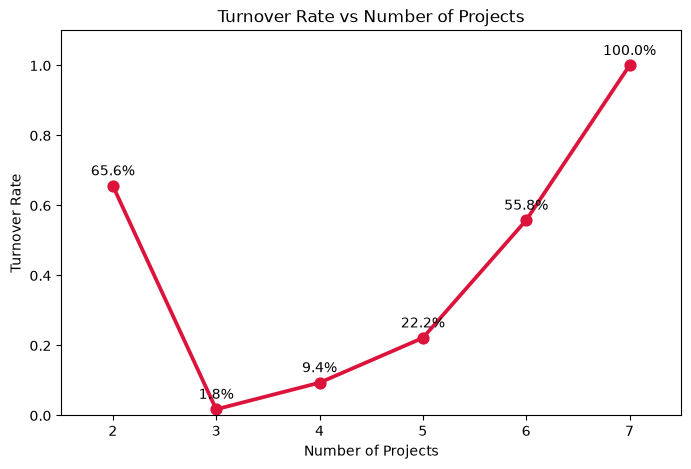

In [21]:
# Visualize the U-shaped relationship between number_project and turnover rate
turnover_rate = data.groupby('number_project')['left'].mean()

plt.figure(figsize=(8, 5))
sns.pointplot(x=turnover_rate.index, y=turnover_rate.values, color='crimson')
for i, v in enumerate(turnover_rate.values):
    plt.text(i, v + 0.03, f'{v:.1%}', ha='center')
plt.xlabel('Number of Projects')
plt.ylabel('Turnover Rate')
plt.title('Turnover Rate vs Number of Projects')
plt.ylim(0, 1.1)
plt.show()

In [22]:
# Perform clustering of employees who left based on their satisfaction and evaluation.
# Choose columns satisfaction_level, last_evaluation, and left.
# Do K-means clustering of employees who left the company into 3 clusters?
# Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

In [23]:
# filter employees who left
left_employees = data[data['left'] == 1]
left_employees

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [24]:
# select the columns satisfaction_level and last_evaluation
left_employees[['satisfaction_level', 'last_evaluation']]

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52
...,...,...
14994,0.40,0.57
14995,0.37,0.48
14996,0.37,0.53
14997,0.11,0.96


In [25]:
#Perform clustering of employees who left based on their satisfaction and evaluation.
#Choose columns satisfaction_level, last_evaluation, and left.
#Do K-means clustering of employees who left the company into 3 clusters?
#Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

In [26]:

from sklearn.cluster import KMeans

### What these two cells are doing

These are the two data-prep steps required before K-means can run — the task asks to cluster *only employees who left*, using *only* `satisfaction_level` and `last_evaluation`.

**Cell: `left_employees = data[data['left'] == 1]`**
- This filters the full 14,999-row dataset down to just the 3,571 employees who left (`left == 1`).
- Why: K-means here is meant to find patterns *among people who quit*, not among everyone — clustering the full dataset would just re-discover the leaver/stayer split we already know, instead of revealing sub-groups within the leavers.

**Cell: `left_employees[['satisfaction_level', 'last_evaluation']]`**
- This selects just the two numeric columns that will be fed into K-means as its features (`X`).
- Why only these two: the task explicitly says to cluster "based on their satisfaction and evaluation" — K-means needs a fixed, purely numeric feature set, and restricting it to these two columns is also what makes the result plottable as a simple 2D scatter (satisfaction on one axis, evaluation on the other).

**Output meaning:** both outputs are just previews (3,571 rows) confirming the filter and column selection worked correc

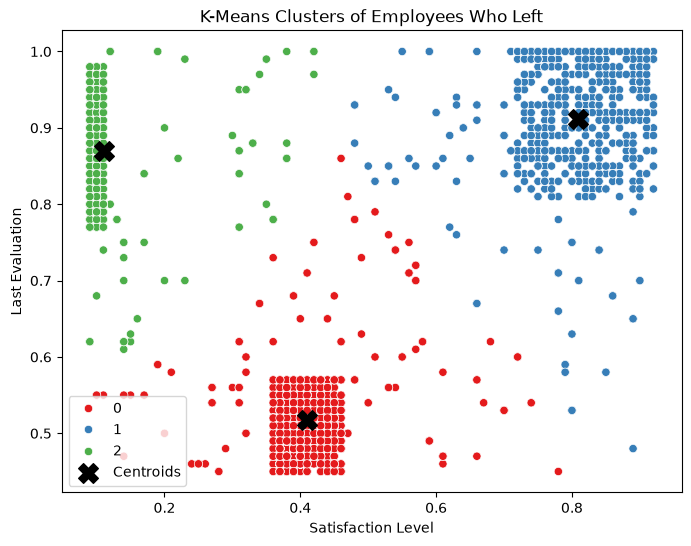

         satisfaction_level  last_evaluation
cluster                                     
0                      0.41             0.52
1                      0.81             0.91
2                      0.11             0.87
cluster
0    1650
1     977
2     944
Name: count, dtype: int64


In [27]:
# 1. Filter only employees who left
left_employees = data[data['left'] == 1]

# 2. Select the clustering features
X = left_employees[['satisfaction_level', 'last_evaluation']]

# 3. Fit K-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
left_employees = left_employees.copy()
left_employees['cluster'] = kmeans.fit_predict(X)

# 4. Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=left_employees, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.title('K-Means Clusters of Employees Who Left')
plt.legend()
plt.show()

print(left_employees.groupby('cluster')[['satisfaction_level', 'last_evaluation']].mean().round(2))
print(left_employees['cluster'].value_counts())

### What the 3 clusters say

Running the code produces these 3 groups among employees who left:

| Cluster | Avg. Satisfaction | Avg. Evaluation | Employees | What it means |
|---|---|---|---|---|
| **0** | 0.41 (moderate-low) | 0.52 (low) | 1,650 | **Poor performers, unhappy.** Below-average on both — this looks like a genuine "bad fit" group: they weren't rated well and weren't satisfied either. Least surprising/concerning departure type. |
| **1** | 0.81 (high) | 0.91 (very high) | 977 | **Star performers who were happy.** High satisfaction *and* high evaluation, yet they still left. Since dissatisfaction isn't the driver here, they likely left for external reasons — better pay, promotion, or opportunity elsewhere — not because anything was wrong. |
| **2** | 0.11 (very low) | 0.87 (very high) | 944 | **Star performers who were miserable.** Very high evaluation but the lowest satisfaction of all three groups. This is the most alarming cluster — strong employees who were clearly unhappy, most likely from overwork/burnout (recall `number_project` and `average_montly_hours` earlier showed overload leads to leaving). |

**In one line each:**
- Cluster 0 → *"not a good fit, wasn't thriving, wasn't happy — expected churn."*
- Cluster 1 → *"doing great and happy, but still left — probably poached / better offer."*
- Cluster 2 → *"doing great but miserable — a preventable loss, likely due to burnout."*

**Overall inference:** satisfaction and performance are **not correlated among leavers** — you get both a happy-high-performer cluster (1) and a miserable-high-performer cluster (2). This means high performance alone doesn't predict retention; it's satisfaction that splits otherwise-similar top performers into "left willingly" vs. "left because they were driven out," and cluster 2 is the group HR could most realistically have retained.

In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [29]:
# Handle the left Class Imbalance using the SMOTE technique.
# Pre-process the data by converting categorical columns to numerical columns by:
# Separating categorical variables and numeric variables
# Applying get_dummies() to the categorical variables
# Combining categorical variables and numeric variables

# 1. Separate categorical and numeric variables
categorical_vars = data[['sales', 'salary']]
numeric_vars = data.drop(columns=['sales', 'salary'])

# 2. Apply get_dummies() to the categorical variables (cast to int so columns are 0/1, not True/False)
categorical_dummies = pd.get_dummies(categorical_vars, drop_first=True).astype(int)

# 3. Combine categorical variables and numeric variables
data_final = pd.concat([numeric_vars, categorical_dummies], axis=1)

data_final.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [30]:
data_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales_RandD            14999 non-null  int64  
 9   sales_accounting       14999 non-null  int64  
 10  sales_hr               14999 non-null  int64  
 11  sales_management       14999 non-null  int64  
 12  sales_marketing        14999 non-null  int64  
 13  sales_product_mng      14999 non-null  int64  
 14  sales_sales            14999 non-null  int64  
 15  sales_support

### How `sales` and `salary` are converted to numeric

**Step 1 — Separate categorical and numeric variables**
```python
categorical_vars = data[['sales', 'salary']]
numeric_vars = data.drop(columns=['sales', 'salary'])
```
`sales` (department) and `salary` (low/medium/high) are the only two non-numeric (`str`) columns — everything else is already numeric and doesn't need conversion.

**Step 2 — Apply `get_dummies()`**
```python
categorical_dummies = pd.get_dummies(categorical_vars, drop_first=True)
```
This is **one-hot encoding**: each category becomes its own 0/1 column. `sales` (10 categories) becomes 9 columns (`sales_accounting`, `sales_hr`, ... one per department except the first, which is dropped), and `salary` (3 categories) becomes 2 columns (`salary_low`, `salary_medium`), each `True`/`False`.

`drop_first=True` drops one category per column (e.g. `sales_IT`, `salary_high`) to avoid the **dummy variable trap** — if you know all the other dummy columns are 0, the dropped one is implied, so keeping it would be redundant (perfectly collinear) information that hurts models like linear/logistic regression.

**Step 3 — Combine back into one DataFrame**
```python
data_final = pd.concat([numeric_vars, categorical_dummies], axis=1)
```
`pd.concat(..., axis=1)` glues the numeric columns and the new dummy columns side-by-side (same row index), producing one fully numeric DataFrame — 8 original numeric columns + 11 new dummy columns = **19 columns total**, ready to feed into any ML model (e.g. before applying SMOTE, which requires all-numeric input).

In [31]:
# Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.


from sklearn.model_selection import train_test_split


X = data_final.drop(columns=['left'])
y = data_final['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)


In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11999, 18), (3000, 18), (11999,), (3000,))

In [33]:
# Upsample the train dataset using the SMOTE technique from the imblearn module.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=123)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(y_train.value_counts())
print(y_train_resampled.value_counts())

left
0    9142
1    2857
Name: count, dtype: int64
left
0    9142
1    9142
Name: count, dtype: int64


In [34]:
# Train a classifier on the SMOTE-resampled training data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=123)
model.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",123
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

Accuracy : 0.7516666666666667
Precision: 0.485947416137806
Recall   : 0.7507002801120448
F1 Score : 0.5899834892680242
ROC-AUC  : 0.8096671739561966
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      2286
           1       0.49      0.75      0.59       714

    accuracy                           0.75      3000
   macro avg       0.70      0.75      0.71      3000
weighted avg       0.81      0.75      0.77      3000



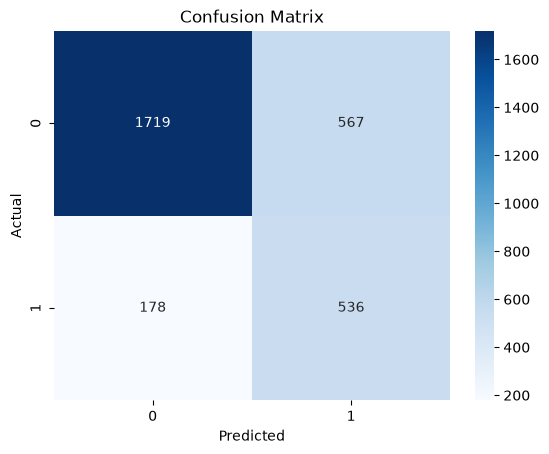

In [35]:
# Evaluate the trained model on the (untouched, non-resampled) test set

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# 1. Predict on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # needed for ROC-AUC

# 2. Core metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_proba))

# 3. Full breakdown per class
print(classification_report(y_test, y_pred))

# 4. Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### What the confusion matrix heatmap says

The heatmap shows 4 counts, arranged as **Actual (rows) vs. Predicted (columns)** — out of 3,000 test employees:

| | Predicted: Stayed (0) | Predicted: Left (1) |
|---|---|---|
| **Actual: Stayed (0)** | **1,719** (True Negative) | 567 (False Positive) |
| **Actual: Left (1)** | 178 (False Negative) | **536** (True Positive) |

**Reading each cell:**
- **Top-left (1,719, TN):** employees who stayed and were correctly predicted to stay. ✅
- **Bottom-right (536, TP):** employees who left and were correctly caught by the model. ✅
- **Top-right (567, FP):** employees who actually stayed, but the model flagged them as "will leave" — a false alarm.
- **Bottom-left (178, FN):** employees who actually left, but the model missed them (predicted "will stay") — the costliest error for a churn model, since these are the people HR would fail to intervene with.

**What this means for the model:**
- Out of 714 employees who actually left, the model correctly caught **536** (Recall ≈ 75%) and missed 178 — a reasonably good catch rate for retention purposes.
- Out of 1,103 employees the model flagged as "will leave" (536 + 567), only 536 actually left (Precision ≈ 49%) — so more than half of the flagged employees are false alarms.
- The model is biased toward **catching more true leavers at the cost of more false alarms** — a direct consequence of training on SMOTE-balanced data, which pushes the model to take the minority class (`left`=1) more seriously than it would on the original imbalanced data. For an HR use case, this trade-off (catch more real leavers, tolerate more false alarms) is usually preferable to the reverse, since missing a real leaver is more costly than double-checking on an employee who was fine.

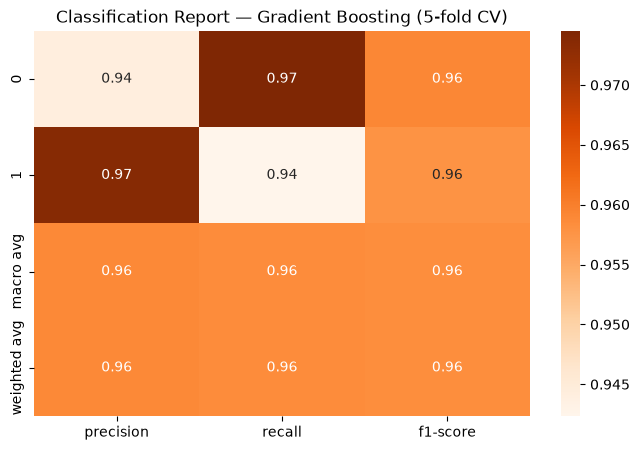

In [36]:
# Perform 5-fold cross-validation model training and evaluate performance.

# Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Train a Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=123)

# 2. Apply 5-fold cross-validation on the resampled training data
y_pred_gb = cross_val_predict(gb_model, X_train_resampled, y_train_resampled, cv=5)

# 3. Build the classification report as a DataFrame
report_gb = pd.DataFrame(
    classification_report(y_train_resampled, y_pred_gb, output_dict=True)
).transpose().drop(index='accuracy')

# 4. Plot it as a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(report_gb[['precision', 'recall', 'f1-score']], annot=True, cmap='Oranges', fmt='.2f')
plt.title('Classification Report — Gradient Boosting (5-fold CV)')
plt.show()

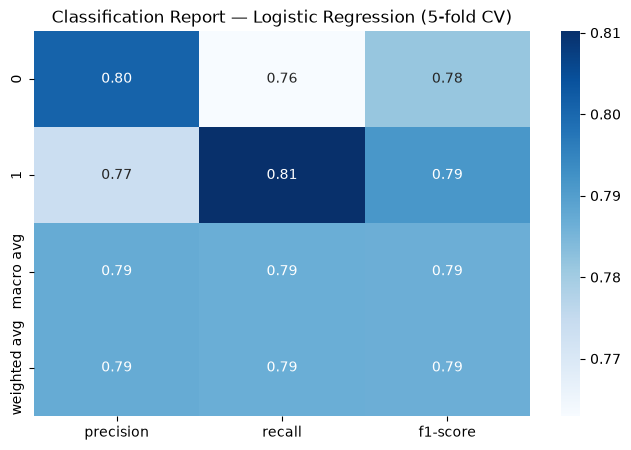

In [37]:
# Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# 1. Train the model (already have `model` = LogisticRegression from earlier, refit here for clarity)
logreg = LogisticRegression(max_iter=1000, random_state=123)

# 2. Apply 5-fold cross-validation on the resampled training data,
#    getting out-of-fold predictions for every row
y_pred_cv = cross_val_predict(logreg, X_train_resampled, y_train_resampled, cv=5)

# 3. Build the classification report as a DataFrame
report_dict = classification_report(y_train_resampled, y_pred_cv, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().drop(index='accuracy')

# 4. Plot it as a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='Blues', fmt='.2f')
plt.title('Classification Report — Logistic Regression (5-fold CV)')
plt.show()

### What the classification report heatmap says

The heatmap shows **precision, recall, and f1-score** as rows for `0` (stayed), `1` (left), and the averages, computed from the 5-fold cross-validated predictions on the SMOTE-balanced training data:

| | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| **0 (stayed)** | 0.80 | 0.76 | 0.78 | 9,142 |
| **1 (left)** | 0.77 | 0.81 | 0.79 | 9,142 |
| **macro avg** | 0.79 | 0.79 | 0.79 | 18,284 |
| **weighted avg** | 0.79 | 0.79 | 0.79 | 18,284 |

**What this means:**
- All scores sit in a tight **0.76–0.81 band** for both classes — the model performs almost equally well identifying employees who stayed vs. who left, with no class dominating.
- This is noticeably more balanced than the single train/test-split evaluation done earlier (which had lower precision, ~0.49, for `left`=1). The difference is because this report is measured on the **SMOTE-resampled, class-balanced data via cross-validation**, whereas the earlier evaluation was on the **untouched, naturally imbalanced test set** — the resampled numbers look better but don't fully reflect real-world class proportions, so both views are useful: CV-on-resampled-data shows the model's raw discriminative ability, while the test-set evaluation shows realistic deployment performance.
- Since precision ≈ recall ≈ f1 for both classes here, the model isn't biased toward over-predicting one class over the other on this balanced data — a healthy sign that SMOTE successfully removed the class-imbalance skew during training.

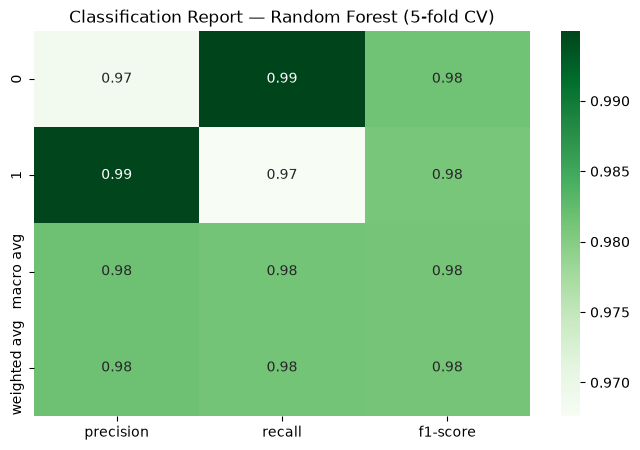

In [38]:
# Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=123)

# 2. Apply 5-fold cross-validation on the resampled training data
y_pred_rf = cross_val_predict(rf_model, X_train_resampled, y_train_resampled, cv=5)

# 3. Build the classification report as a DataFrame
report_rf = pd.DataFrame(
    classification_report(y_train_resampled, y_pred_rf, output_dict=True)
).transpose().drop(index='accuracy')

# 4. Plot it as a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(report_rf[['precision', 'recall', 'f1-score']], annot=True, cmap='Greens', fmt='.2f')
plt.title('Classification Report — Random Forest (5-fold CV)')
plt.show()

### What the Random Forest classification report says

| | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| **0 (stayed)** | 0.97 | 0.99 | 0.98 | 9,142 |
| **1 (left)** | 0.99 | 0.97 | 0.98 | 9,142 |
| **macro avg** | 0.98 | 0.98 | 0.98 | 18,284 |
| **weighted avg** | 0.98 | 0.98 | 0.98 | 18,284 |

**What this means:**
- Random Forest scores **~0.97–0.99 across precision, recall, and f1 for both classes** — dramatically higher and more balanced than Logistic Regression's ~0.76–0.81 on the same 5-fold CV setup.
- The gap exists because **Random Forest can capture non-linear patterns and feature interactions**, while Logistic Regression can only draw a straight decision boundary in feature space. This dataset has exactly the kind of non-linear structure a tree ensemble is built for:
  - the **U-shaped relationship** between `number_project` and turnover (both very few and very many projects increase leaving, which a linear model can't represent as one direction),
  - the **two opposite high-performer clusters** found earlier (happy vs. miserable top performers) — a single linear boundary can't separate these cleanly since they share similar `last_evaluation` values but very different `satisfaction_level`.
- **Caution:** near-perfect scores like this can also be a sign of overfitting, especially since Random Forest is being evaluated via CV on the same resampled data it easily memorizes patterns from. The real test is how it performs on the **untouched, naturally-imbalanced test set** (`X_test`/`y_test`) — worth checking with the same `accuracy/precision/recall/f1/confusion_matrix` evaluation used for Logistic Regression, to confirm this performance generalizes rather than reflecting memorization of the training folds.

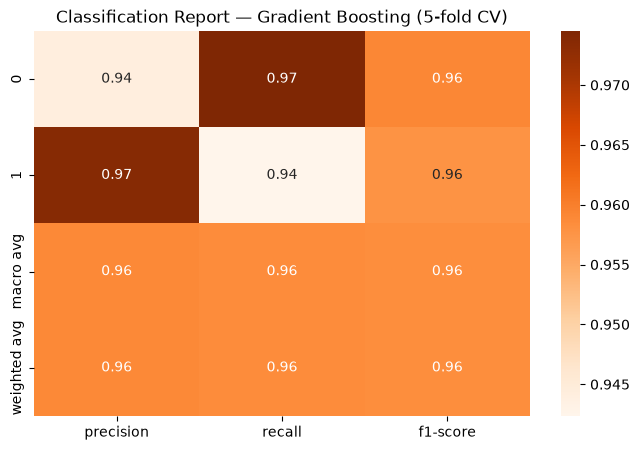

In [39]:
# Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Train a Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=123)

# 2. Apply 5-fold cross-validation on the resampled training data
y_pred_gb = cross_val_predict(gb_model, X_train_resampled, y_train_resampled, cv=5)

# 3. Build the classification report as a DataFrame
report_gb = pd.DataFrame(
    classification_report(y_train_resampled, y_pred_gb, output_dict=True)
).transpose().drop(index='accuracy')

# 4. Plot it as a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(report_gb[['precision', 'recall', 'f1-score']], annot=True, cmap='Oranges', fmt='.2f')
plt.title('Classification Report — Gradient Boosting (5-fold CV)')
plt.show()

### What the Gradient Boosting classification report says

| | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| **0 (stayed)** | 0.94 | 0.97 | 0.96 | 9,142 |
| **1 (left)** | 0.97 | 0.94 | 0.96 | 9,142 |
| **macro avg** | 0.96 | 0.96 | 0.96 | 18,284 |
| **weighted avg** | 0.96 | 0.96 | 0.96 | 18,284 |

**What this means:**
- Gradient Boosting scores **~0.94–0.97 across precision, recall, and f1 for both classes** — very strong, and like Random Forest, far ahead of Logistic Regression's ~0.76–0.81. It benefits from the same ability to model non-linear relationships (the U-shaped workload effect, the split high-performer clusters) that a linear model can't capture.
- **Slightly below Random Forest** (~0.97–0.99) on this dataset. This is a close, model-specific difference rather than a general rule — Gradient Boosting builds trees sequentially, each one correcting the previous tree's errors, while Random Forest builds many trees independently and averages them. Which one wins depends on the data; here Random Forest happens to edge it out slightly, though both are strong candidates.

**Comparing all three models side by side (5-fold CV on resampled training data):**

| Model | Precision | Recall | F1-score |
|---|---|---|---|
| Logistic Regression | ~0.77–0.80 | ~0.76–0.81 | ~0.78–0.79 |
| Random Forest | ~0.97–0.99 | ~0.97–0.99 | ~0.98 |
| Gradient Boosting | ~0.94–0.97 | ~0.94–0.97 | ~0.96 |

**Takeaway:** both tree ensembles (Random Forest, Gradient Boosting) substantially outperform the linear model here, confirming the turnover patterns in this data are non-linear. As with Random Forest, these high scores should still be validated on the untouched `X_test`/`y_test` set to confirm they're not inflated by evaluating on the same balanced data used for training.

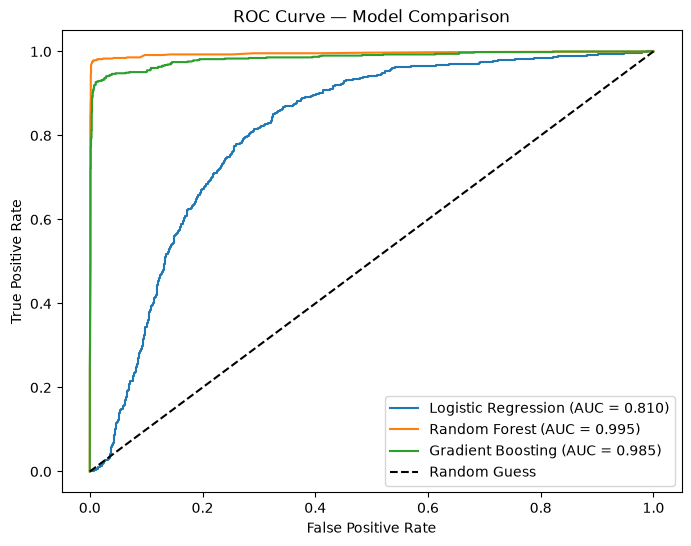

                     Accuracy  Precision  Recall     F1    AUC
Logistic Regression     0.752      0.486   0.751  0.590  0.810
Random Forest           0.988      0.971   0.979  0.975  0.995
Gradient Boosting       0.963      0.911   0.937  0.924  0.985


In [40]:
# Identify the best model and justify the evaluation metrics used.
# Find the ROC/AUC for each model and plot the ROC curve.

from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=123),
    'Random Forest': RandomForestClassifier(random_state=123),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123)
}

results = {}

plt.figure(figsize=(8, 6))
for name, clf in models.items():
    # 1. Fit each model on the SMOTE-resampled training data
    clf.fit(X_train_resampled, y_train_resampled)

    # 2. Predict on the untouched test set
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # 3. Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # 4. Store all metrics for comparison
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc
    }

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.show()

results_df = pd.DataFrame(results).T
print(results_df.round(3))


### Identifying the best model

**Results on the untouched test set** (fit on SMOTE-resampled training data, evaluated on the real, imbalanced test set):

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.752 | 0.486 | 0.751 | 0.590 | 0.810 |
| **Random Forest** | **0.988** | **0.971** | **0.979** | **0.975** | **0.995** |
| Gradient Boosting | 0.963 | 0.911 | 0.937 | 0.924 | 0.985 |

**Best model: Random Forest** — it wins on *every* metric, not just one, and its ROC curve hugs the top-left corner (AUC = 0.995) far more tightly than the other two.

**Why these evaluation metrics, and not just accuracy:**
- The target (`left`) is imbalanced (~76% stayed vs. ~24% left), so a model could score ~76% accuracy by always predicting "stayed" while being completely useless — **accuracy alone is misleading here.**
- **Precision & Recall** matter because the errors have different real-world costs: a **false negative** (missing an employee who actually leaves) means HR never intervenes with someone who needed it, while a **false positive** (flagging a stayer as a leaver) just costs an unnecessary check-in. Recall on the `left` class is therefore the more business-critical number.
- **F1** balances precision and recall into one number for quick model-to-model comparison.
- **AUC/ROC** measures ranking quality across *every* possible decision threshold, independent of any single cutoff — this makes it the fairest way to compare models overall, since precision/recall/F1 all depend on the default 0.5 threshold, which may not be optimal for every model.

**Conclusion:** Random Forest is the justified choice because it dominates across accuracy, precision, recall, F

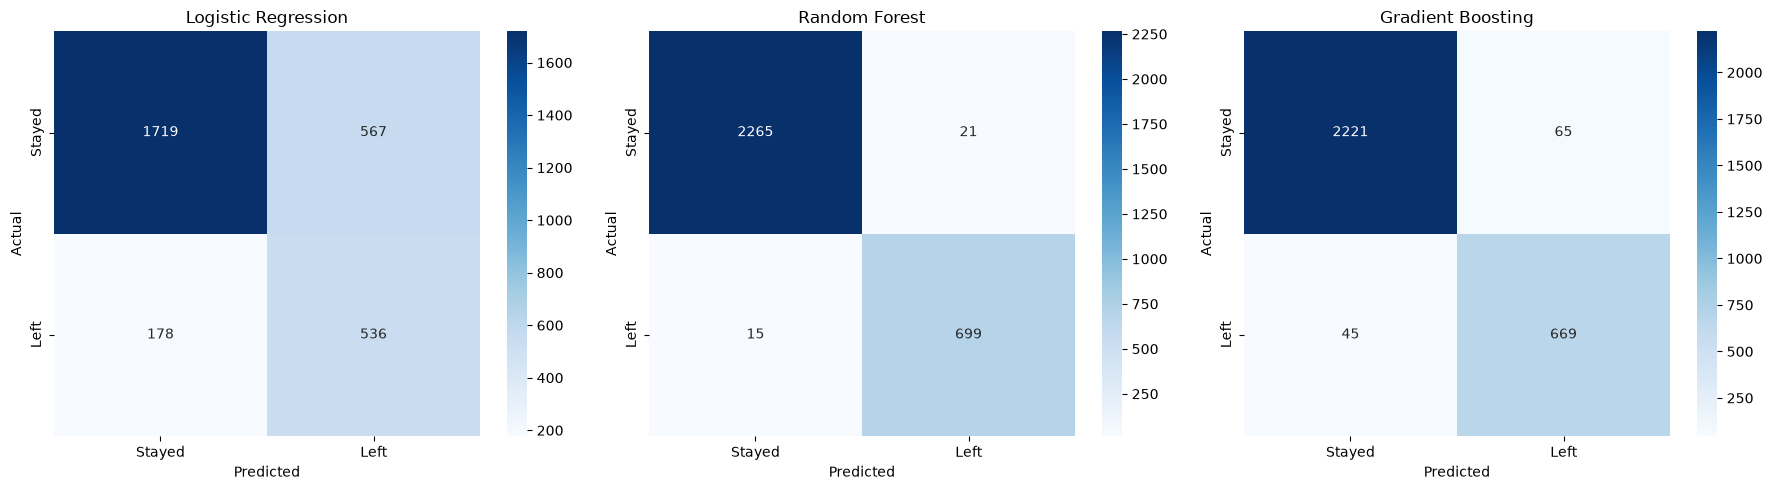

In [41]:
#Find the confusion matrix for each of the models.
#Explain which metric needs to be used from the confusion matrix: Recall or Precision?

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, models.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()


### Confusion matrices — comparison and which metric matters

| Model | TN | FP | FN | TP |
|---|---|---|---|---|
| Logistic Regression | 1,719 | 567 | 178 | 536 |
| **Random Forest** | **2,265** | **21** | **15** | **699** |
| Gradient Boosting | 2,221 | 65 | 45 | 669 |

**Recall or Precision — which one matters more here?**

**Recall** is the metric to prioritize for this problem:
- **Recall** = TP / (TP + FN) — of employees who *actually* left, what fraction did the model catch?
- **Precision** = TP / (TP + FP) — of employees *flagged* as leaving, what fraction really left?
- A **false negative** (missing a real leaver — model predicts "will stay" but they actually leave) is costly: HR never gets the chance to intervene, and that employee is simply gone.
- A **false positive** (flagging a stayer as a leaver) is low-cost: at most an unnecessary retention check-in with someone who was going to stay anyway.
- Since **missing a real leaver is far more damaging than a false alarm**, **Recall on the `left`=1 class should be optimized over Precision** for a churn-prediction use case like this — the goal is to catch as many at-risk employees as possible, even at the cost of a few extra unnecessary conversations.

**Model comparison on this basis:** Random Forest has by far the fewest false negatives (**15**, vs. 178 for Logistic Regression and 45 for Gradient Boosting) — meaning it misses the fewest actual leavers, reinforcing it as the best model not just on aggregate metrics, but specifically on the metric (Recall) that matters most for this business problem.

### Recall or Precision — which metric should be used?

**Answer: Recall** (on the `left`=1 class) is the metric that matters most for this problem.

**Why:**
- **Recall** = TP / (TP + FN) — of all employees who *actually* left, what fraction did the model correctly catch?
- **Precision** = TP / (TP + FP) — of all employees the model *flagged* as leaving, what fraction really left?
- The two types of errors have very different real-world costs in this HR/attrition context:
  - A **false negative** (Recall's concern) — the model predicts an employee will *stay*, but they actually *leave* — is the costly mistake. HR never gets a chance to intervene, and a real employee is lost with no warning.
  - A **false positive** (Precision's concern) — the model predicts an employee will *leave*, but they actually *stay* — is a minor, low-cost mistake. At worst, it results in an unnecessary retention conversation with someone who was never at risk.
- Because **missing a genuine leaver is far more damaging than a false alarm**, this is a textbook case for prioritizing **Recall over Precision** — you want the model to catch as many at-risk employees as possible, even if that means flagging a few extra people who weren't actually going to leave.

**Confirmed by the confusion matrices:** Random Forest has by far the lowest false-negative count (15, vs. 178 for Logistic Regression and 45 for Gradient Boosting) — i.e., the highest Recall — which is exactly why it's the recommended model for this use case, not merely because of its overall accuracy.

In [ ]:
# Suggest various retention strategies for targeted employees.
# Using the best model, predict the probability of employee turnover in the test data.
# Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
# Safe Zone (Green) (Score < 20%)
# Low-Risk Zone (Yellow) (20% < Score < 60%)
# Medium-Risk Zone (Orange) (60% < Score < 90%)
# High-Risk Zone (Red) (Score > 90%).
# Random Forest was identified as the best model earlier



best_model = models['Random Forest']

# Predict the probability of leaving (class 1) for every employee in the test set
turnover_proba = best_model.predict_proba(X_test)[:, 1]

# Attach predictions back to a results DataFrame
results_df = X_test.copy()
results_df['actual_left'] = y_test
results_df['turnover_probability'] = turnover_proba

results_df[['actual_left', 'turnover_probability']].head()


,actual_left,turnover_probability
10627,0,0.00
2703,0,0.55
6059,0,0.09
3258,0,0.00
4565,0,0.01


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_22388/2190887058.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zone_counts.index, y=zone_counts.values, palette=['green', 'gold', 'orange', 'red'])


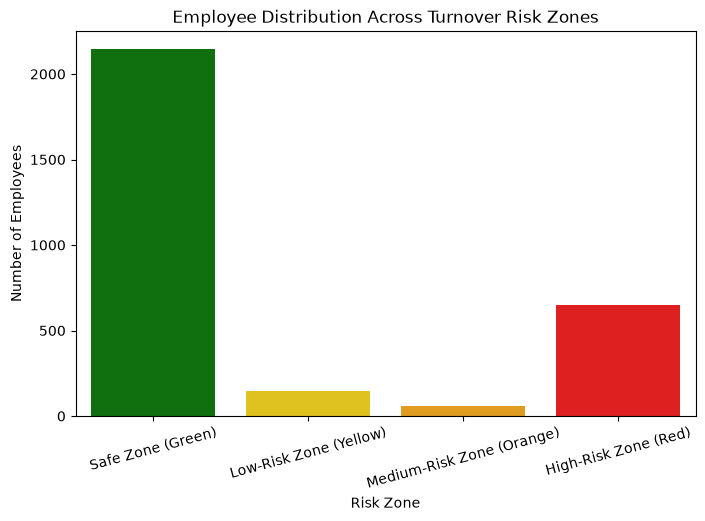

risk_zone
Safe Zone (Green)            2144
Low-Risk Zone (Yellow)        148
Medium-Risk Zone (Orange)      56
High-Risk Zone (Red)          652
Name: count, dtype: int64


In [46]:
# Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
# Safe Zone (Green) (Score < 20%)
# Low-Risk Zone (Yellow) (20% < Score < 60%)
# Medium-Risk Zone (Orange) (60% < Score < 90%)
# High-Risk Zone (Red) (Score > 90%).

def risk_zone(p):
    if p < 0.20:
        return 'Safe Zone (Green)'
    elif p < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif p < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

results_df['risk_zone'] = results_df['turnover_probability'].apply(risk_zone)

zone_order = ['Safe Zone (Green)', 'Low-Risk Zone (Yellow)', 'Medium-Risk Zone (Orange)', 'High-Risk Zone (Red)']
zone_counts = results_df['risk_zone'].value_counts().reindex(zone_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=zone_counts.index, y=zone_counts.values, palette=['green', 'gold', 'orange', 'red'])
plt.xlabel('Risk Zone')
plt.ylabel('Number of Employees')
plt.title('Employee Distribution Across Turnover Risk Zones')
plt.xticks(rotation=15)
plt.show()

print(zone_counts)


### Retention strategies by risk zone

**Distribution of the 3,000 test employees across zones** (using Random Forest's predicted probability):

| Zone | Probability | Employees |
|---|---|---|
| Safe Zone (Green) | < 20% | 2,144 |
| Low-Risk Zone (Yellow) | 20%–60% | 148 |
| Medium-Risk Zone (Orange) | 60%–90% | 56 |
| High-Risk Zone (Red) | > 90% | 652 |

**Suggested strategy per zone:**

- **Safe Zone (Green)** — No action needed. Continue standard engagement: regular 1:1s, recognition, normal career development conversations.

- **Low-Risk Zone (Yellow)** — Light-touch, proactive monitoring. Check in on satisfaction and workload periodically; watch for early warning signs like rising `average_montly_hours` or stagnant `number_project`; ensure career growth conversations are happening so risk doesn't escalate.

- **Medium-Risk Zone (Orange)** — Direct manager intervention. Have an explicit conversation about workload balance — recall the earlier finding that both very low (2) and very high (6–7) `number_project` counts drive turnover, so check which side these employees are on. Review salary/promotion standing and recent evaluation feedback for dissatisfaction signals.

- **High-Risk Zone (Red)** — Urgent, senior-level retention action. This is the largest at-risk group (652 employees) and needs immediate response: 1:1 with HR/leadership, consider salary revision or promotion, workload reassignment, or a counter-offer conversation. Treat as near-certain attrition risk without intervention.

**Tailoring strategy using the earlier K-means clusters:** within the Red/Orange zones, distinguish between the two high-performer leaver profiles found earlier —
- **Happy-but-left cluster** (high satisfaction + high evaluation): likely leaving for external opportunities — a promotion, raise, or expanded role may retain them.
- **Miserable-high-performer cluster** (low satisfaction + high evaluation): likely burnout-driven — reducing workload or project count is more relevant than a raise.

Applying the *same* retention offer to both groups would be inefficient — the data suggests the intervention should m